
# DeepONet + 2D Burgers + Laplace Approximation

This notebook builds a compact scientific machine learning example around a **scalar 2D viscous Burgers equation**. The workflow is:

1. Generate a small operator-learning dataset by solving Burgers from random smooth initial conditions.
2. Train a **DeepONet2D** surrogate with standard MAP training.
3. Fit a **last-layer Laplace approximation** with the existing `Deep-UQ` implementation.
4. Visualize predictive mean, error, and spatial epistemic uncertainty.

The setup is intentionally CPU-friendly. It is designed to show the operator-learning workflow clearly, not to be a high-fidelity CFD benchmark.



## Why this model structure works with Laplace in Deep-UQ

`LaplaceWrapper` in this package expects a model that consumes a **single input tensor** and produces a prediction tensor. A standard DeepONet often takes both the input function and coordinates during `forward`, but that would not fit the current Laplace API.

To keep the uncertainty tooling unchanged, `DeepONet2D` stores a **fixed query grid** internally:

- the **branch network** consumes the sampled initial field,
- the **trunk network** evaluates the fixed spatial grid,
- a final **linear readout head** maps fused branch/trunk features to the field values.

That last linear head is exactly what we place the **last-layer Laplace approximation** on.


## How to read this notebook

A new user can read this notebook in four passes:

1. **Problem setup**: understand the PDE, the input/output operator map, and how the dataset is generated.
2. **Modeling choice**: see how `DeepONet2D` is adapted so it works cleanly with the existing `LaplaceWrapper` API.
3. **MAP training**: inspect the deterministic surrogate first and verify that it learns the field map reasonably well.
4. **Uncertainty layer**: only after the MAP model is behaving well do we fit Laplace and inspect the resulting uncertainty maps.

A practical reading tip: focus first on the markdown cells and the plots. The code comments are there so you can return later and understand how each implementation block supports the visual result.

In [262]:
# Notebook bootstrap cell
# - Make sure imports resolve to the local repo code in `src/`.
# - This avoids accidentally importing an older installed `deepuq` package.
# - Keep this cell near the top so every later import uses the intended code.

# Notebook bootstrap cell
# - Adds the local src/ directory to Python path so the notebook imports the
#   in-repo deepuq package instead of any older installed package.
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent if PROJECT_ROOT.name == 'sciml' else PROJECT_ROOT.parent

SRC_PATH = str(PROJECT_ROOT / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

In [263]:
# Core imports
# - Standard library: math/random/dataclass utilities.
# - PyTorch + DataLoader for dataset handling and optimization.
# - Deep-UQ: LaplaceWrapper and the reusable DeepONet2D model.
# - Random seeds are fixed for reproducibility of the tutorial figures.

import math
import random
from dataclasses import dataclass

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import LaplaceWrapper
from deepuq.models import DeepONet2D

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda



## Configuration

Two configurations are provided:

- `USE_QUICK_CONFIG = True` keeps the notebook fast.
- `USE_QUICK_CONFIG = False` runs the fuller setting described in the tutorial plan.


### Configuration guide

The main toggles are collected in `ExperimentConfig` so the notebook can be adapted without editing the training or PDE code.

Important fields:

- `USE_QUICK_CONFIG`: if `True`, shrinks the dataset and training budget for a faster demo run.
- `nu` and `final_time`: control how hard the Burgers forecasting problem is.
- `use_early_stopping`: lets you choose between validation-based stopping and always training for the full schedule.
- `grad_match_weight`: controls how strongly we encourage spatial derivative agreement.
- `compare_kron`: enables the optional diagonal-vs-Kronecker Laplace comparison.

For tutorial reading, the default full configuration is more informative because the model and uncertainty maps are cleaner.

In [264]:
# Experiment configuration
# - Keep all high-level knobs in one place so the notebook is easy to tune.
# - `use_early_stopping=False` would force full-schedule training.
# - The default values below are chosen to keep the tutorial stable and informative.

USE_QUICK_CONFIG = False

@dataclass
class ExperimentConfig:
    nu: float = 0.03
    final_time: float = 0.08
    sensor_resolution: int = 16
    field_resolution: int = 32
    n_train: int = 200
    n_val: int = 40
    n_test: int = 40
    n_ood: int = 40
    batch_size: int = 16
    lr: float = 8e-4
    max_lr: float = 2e-3
    epochs: int = 500
    min_epochs: int = 80
    patience: int = 35
    early_stopping_min_delta: float = 1e-5
    use_early_stopping: bool = False
    grad_clip: float = 1.0
    weight_decay: float = 1e-5
    grad_match_weight: float = 0.1
    scheduler_pct_start: float = 0.15
    latent_dim: int = 128
    hidden_dim: int = 128
    depth: int = 4
    laplace_samples: int = 20
    compare_kron: bool = True


config = ExperimentConfig()
if USE_QUICK_CONFIG:
    config.n_train = 96
    config.n_val = 24
    config.n_test = 24
    config.n_ood = 24
    config.epochs = 120
    config.min_epochs = 40
    config.patience = 20
    config.compare_kron = False

config

ExperimentConfig(nu=0.03, final_time=0.08, sensor_resolution=16, field_resolution=32, n_train=200, n_val=40, n_test=40, n_ood=40, batch_size=16, lr=0.0008, max_lr=0.002, epochs=500, min_epochs=80, patience=35, early_stopping_min_delta=1e-05, use_early_stopping=False, grad_clip=1.0, weight_decay=1e-05, grad_match_weight=0.1, scheduler_pct_start=0.15, latent_dim=128, hidden_dim=128, depth=4, laplace_samples=20, compare_kron=True)

## Burgers dataset generation

We generate a small scientific machine learning dataset by solving a scalar 2D viscous Burgers equation

$$
\partial_t u + u(\partial_x u + \partial_y u) = \nu(\partial_{xx}u + \partial_{yy}u)
$$

on the periodic unit square.

### Physical meaning of the dataset

In this notebook, the field $u(x,y,t)$ can be interpreted as a simplified transported quantity, such as a scalar velocity-like field or advected state over a 2D domain.

- the **initial condition** $u_0(x,y)$ is the starting spatial state at time $t=0$,
- the **final field** $u(x,y,T)$ is the evolved state after nonlinear transport and diffusion have acted up to time $T$,
- the viscosity parameter $\nu$ controls how strongly the field smooths out,
- sharper spatial gradients make the prediction task harder because advection and diffusion interact more strongly there.

The operator-learning task is therefore:

- observe the starting field,
- predict the whole field at a later time.

### Why this is scientifically meaningful

Even in this simplified scalar setting, the model must learn a genuine PDE-driven transformation:

- advection transports information across the domain,
- diffusion smooths and damps spatial variation,
- the final solution is not just a local pointwise transform of the initial condition.

This makes the example a real miniature scientific machine learning problem rather than a generic regression toy dataset.

### In-domain vs OOD meaning

- **In-domain data** uses smoother, lower-frequency initial fields similar to training conditions.
- **OOD data** uses rougher and larger-amplitude initial fields.

Physically, the OOD set represents states with more severe gradients and more complex transport structure than the model was calibrated on. This is exactly where we expect predictive uncertainty to increase.

### Dataset helper functions

This helper block does three jobs:

- creates periodic spatial grids,
- samples smooth initial conditions from low-frequency Fourier modes,
- solves the scalar Burgers PDE forward in time.

### Physical interpretation of each helper

- `sample_fourier_initial_conditions(...)` creates a family of smooth starting states. Physically, these are different possible system configurations at time $t=0$.
- `solve_scalar_burgers_batch(...)` evolves those states under nonlinear transport plus diffusion, producing the supervision target at time $T$.
- `make_burgers_dataset(...)` packages the problem into operator-learning input/output pairs: coarse initial state in, fine final field out.

Two implementation details are worth noticing:

- the grid excludes the duplicated endpoint at `x=1` / `y=1`, which is the natural choice for periodic finite differences,
- the PDE solver is intentionally simple and stabilized for teaching purposes, not for high-fidelity scientific simulation.

In [265]:
# PDE and dataset helpers
# - `make_uniform_grid`: periodic spatial grid on [0, 1)^2.
# - `sample_fourier_initial_conditions`: random smooth initial fields.
# - `solve_scalar_burgers_batch`: explicit Burgers solver used to build labels.
# - `make_burgers_dataset`: packages everything into branch inputs + target fields.

def make_uniform_grid(resolution: int) -> torch.Tensor:
    # For a periodic domain we avoid duplicating the x=1 / y=1 endpoint.
    x = torch.linspace(0.0, 1.0, resolution + 1)[:-1]
    y = torch.linspace(0.0, 1.0, resolution + 1)[:-1]
    xx, yy = torch.meshgrid(x, y, indexing="ij")
    return torch.stack([xx, yy], dim=-1)


def sample_fourier_initial_conditions(
    n_samples: int,
    resolution: int,
    *,
    max_mode: int = 3,
    amplitude_scale: float = 1.0,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    grid = make_uniform_grid(resolution)
    x = grid[..., 0]
    y = grid[..., 1]
    fields = []
    for _ in range(n_samples):
        field = torch.zeros_like(x)
        for kx in range(1, max_mode + 1):
            for ky in range(1, max_mode + 1):
                coeffs = torch.randn(4, generator=generator)
                basis = (
                    coeffs[0] * torch.sin(2 * math.pi * kx * x) * torch.sin(2 * math.pi * ky * y)
                    + coeffs[1] * torch.sin(2 * math.pi * kx * x) * torch.cos(2 * math.pi * ky * y)
                    + coeffs[2] * torch.cos(2 * math.pi * kx * x) * torch.sin(2 * math.pi * ky * y)
                    + coeffs[3] * torch.cos(2 * math.pi * kx * x) * torch.cos(2 * math.pi * ky * y)
                )
                field = field + basis / (kx**2 + ky**2)
        field = amplitude_scale * field / field.abs().amax().clamp_min(1e-6)
        fields.append(field)
    return torch.stack(fields, dim=0)


def burgers_step(u: torch.Tensor, dx: float, dt: float, nu: float) -> torch.Tensor:
    ux = (torch.roll(u, shifts=-1, dims=-2) - torch.roll(u, shifts=1, dims=-2)) / (2.0 * dx)
    uy = (torch.roll(u, shifts=-1, dims=-1) - torch.roll(u, shifts=1, dims=-1)) / (2.0 * dx)
    laplace = (
        torch.roll(u, shifts=-1, dims=-2)
        + torch.roll(u, shifts=1, dims=-2)
        + torch.roll(u, shifts=-1, dims=-1)
        + torch.roll(u, shifts=1, dims=-1)
        - 4.0 * u
    ) / (dx**2)
    return u + dt * (-u * (ux + uy) + nu * laplace)


def solve_scalar_burgers_batch(
    initial_fields: torch.Tensor,
    *,
    nu: float,
    final_time: float,
) -> torch.Tensor:
    u = initial_fields.clone()
    resolution = u.shape[-1]
    dx = 1.0 / resolution
    elapsed = 0.0
    step_count = 0
    max_steps = 20000

    while elapsed < final_time and step_count < max_steps:
        max_speed = float(u.abs().amax().clamp_min(1e-3).item())
        adv_dt = 0.08 * dx / max_speed
        diff_dt = 0.10 * dx * dx / max(nu, 1e-6)
        dt = min(adv_dt, diff_dt, final_time - elapsed)

        u = burgers_step(u, dx=dx, dt=dt, nu=nu)
        # The OOD initial conditions are intentionally harder. Keep the explicit
        # solver numerically stable instead of letting a few points blow up.
        u = torch.nan_to_num(u, nan=0.0, posinf=3.0, neginf=-3.0)
        u = u.clamp(-3.0, 3.0)

        elapsed += dt
        step_count += 1

    if step_count >= max_steps:
        raise RuntimeError("Burgers solver hit max_steps before reaching final_time.")
    return u


def downsample_periodic(fields: torch.Tensor, target_resolution: int) -> torch.Tensor:
    fields = fields.unsqueeze(1)
    resized = F.interpolate(fields, size=(target_resolution, target_resolution), mode="bilinear", align_corners=False)
    return resized[:, 0]


def make_burgers_dataset(n_samples: int, *, max_mode: int, amplitude_scale: float, cfg: ExperimentConfig, seed: int):
    gen = torch.Generator().manual_seed(seed)
    fine_init = sample_fourier_initial_conditions(
        n_samples,
        cfg.field_resolution,
        max_mode=max_mode,
        amplitude_scale=amplitude_scale,
        generator=gen,
    )
    fine_final = solve_scalar_burgers_batch(fine_init, nu=cfg.nu, final_time=cfg.final_time)
    coarse_init = downsample_periodic(fine_init, cfg.sensor_resolution)
    return {
        "branch": coarse_init.reshape(n_samples, -1).float(),
        "initial_field": fine_init.float(),
        "target_field": fine_final.float(),
    }

In [266]:
# Build train / validation / test / OOD splits.
# - Train/val/test: smoother initial states that define the model's main support.
# - OOD: rougher, higher-amplitude initial states that are physically harder to evolve.
# - This is the key uncertainty experiment: does the model become less confident
#   when the starting field is more extreme than the training cases?
train_data = make_burgers_dataset(config.n_train, max_mode=3, amplitude_scale=1.0, cfg=config, seed=11)
val_data = make_burgers_dataset(config.n_val, max_mode=3, amplitude_scale=1.0, cfg=config, seed=17)
test_data = make_burgers_dataset(config.n_test, max_mode=3, amplitude_scale=1.0, cfg=config, seed=23)
ood_data = make_burgers_dataset(config.n_ood, max_mode=5, amplitude_scale=1.4, cfg=config, seed=29)

query_grid_2d = make_uniform_grid(config.field_resolution)
query_grid = query_grid_2d.reshape(-1, 2).float()

print(train_data["branch"].shape, train_data["target_field"].shape, query_grid.shape)

torch.Size([200, 256]) torch.Size([200, 32, 32]) torch.Size([1024, 2])


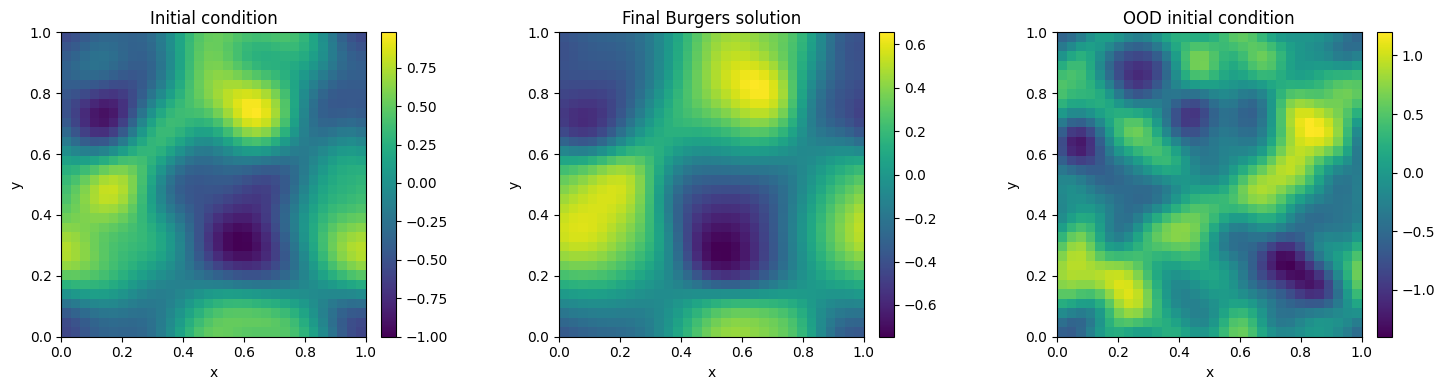

In [267]:
# Small plotting helper used throughout the notebook.
# It keeps all 2D field figures visually consistent.


def plot_field(ax, field, title, cmap="viridis"):
    im = ax.imshow(field, origin="lower", extent=[0, 1, 0, 1], cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

idx = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_field(axes[0], train_data["initial_field"][idx], "Initial condition")
plot_field(axes[1], train_data["target_field"][idx], "Final Burgers solution")
plot_field(axes[2], ood_data["initial_field"][idx], "OOD initial condition")
plt.tight_layout()


## Additional dataset diagnostics

Before training, it helps to inspect more than one sample. The next plots show:

- several in-domain and OOD initial/final field pairs,
- how the OOD dataset differs in amplitude and spatial roughness.

This makes the later uncertainty behavior easier to interpret.

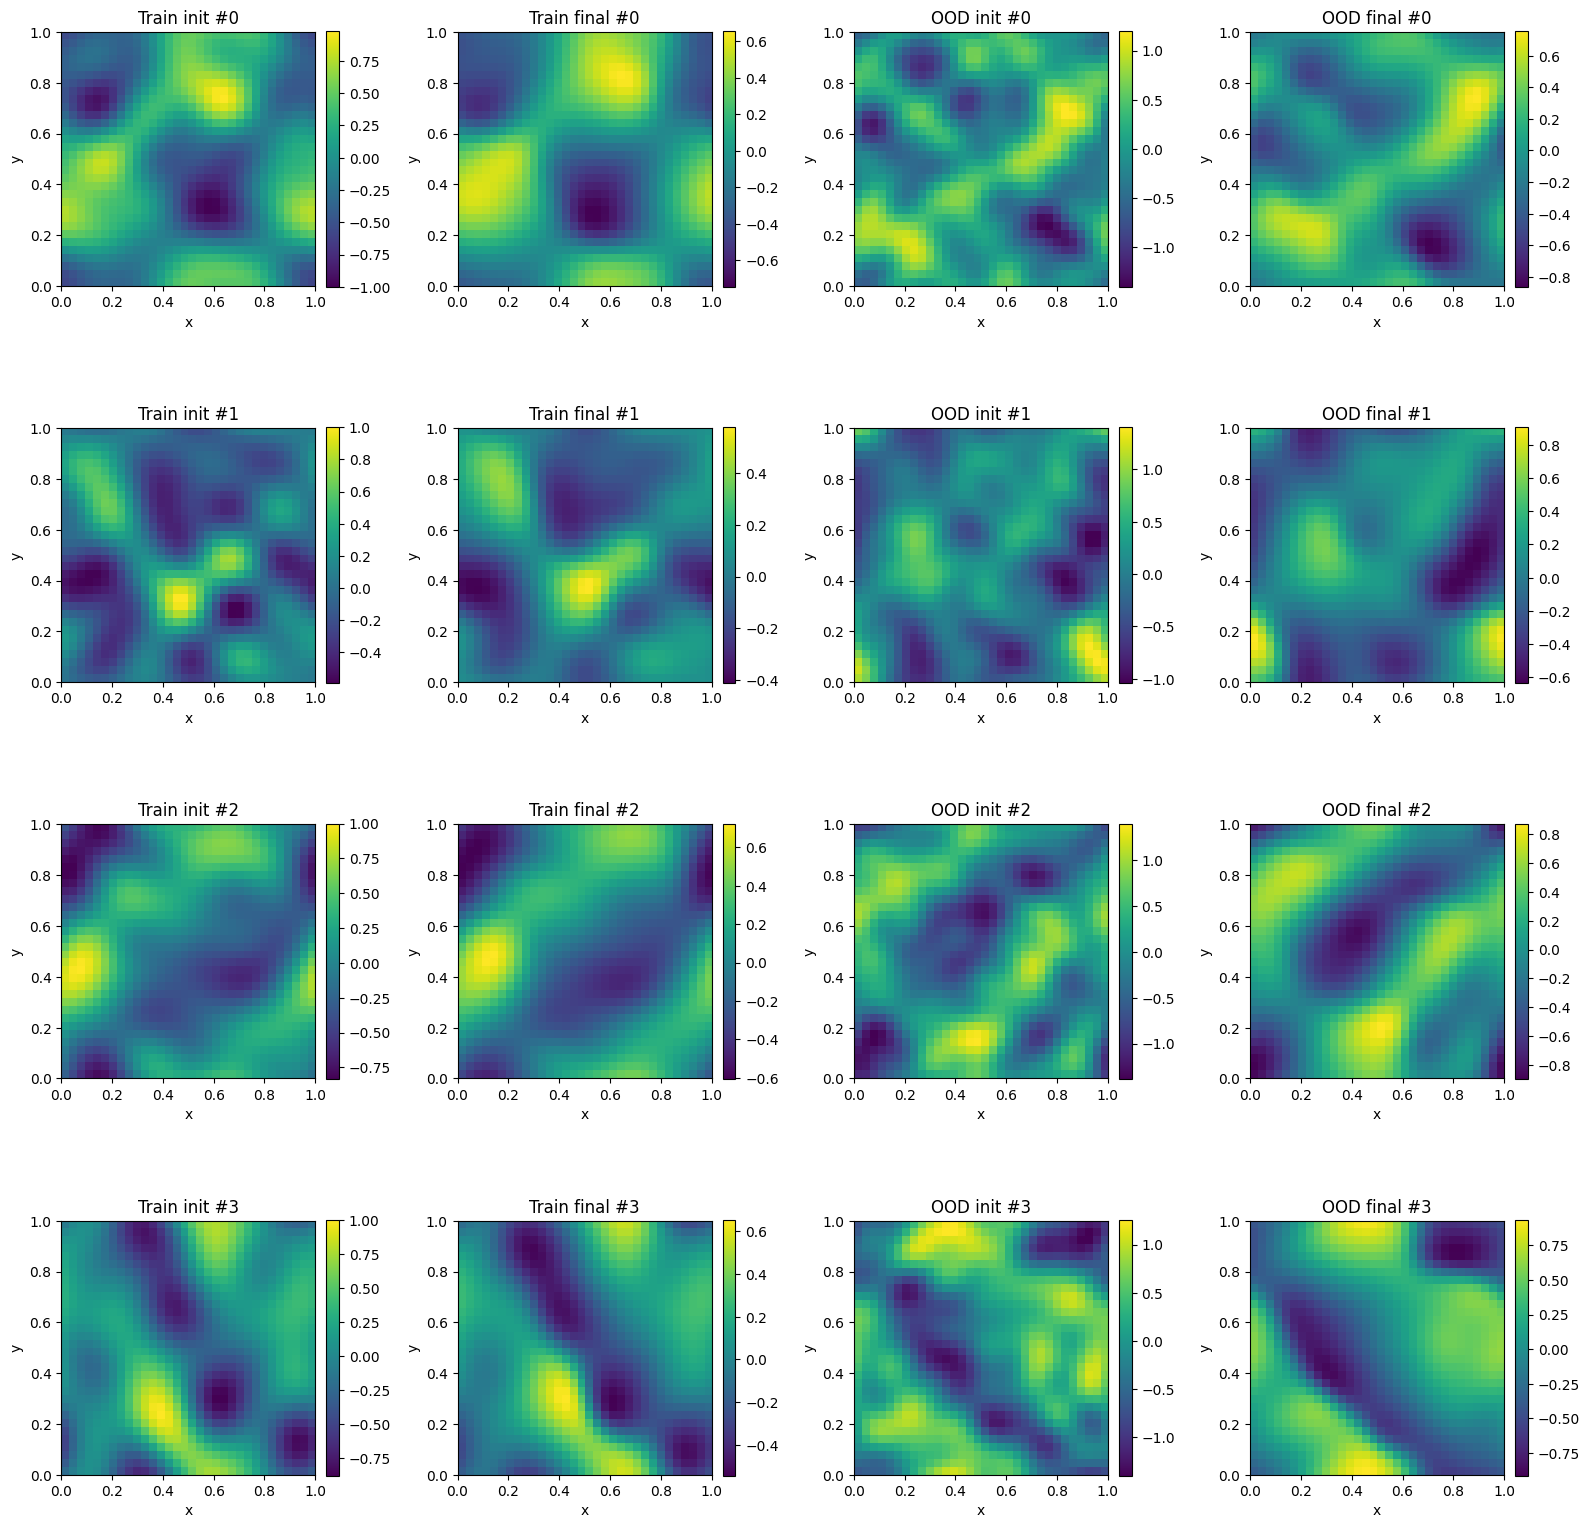

In [268]:
# Quantify how rough a field is via simple finite differences.
# This helps us explain why the OOD set is genuinely harder.

def field_roughness(batch):
    gx = torch.roll(batch, shifts=-1, dims=-2) - batch
    gy = torch.roll(batch, shifts=-1, dims=-1) - batch
    return (gx.square() + gy.square()).mean(dim=(-1, -2))

sample_ids = [0, 1, 2, 3]
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for row, idx in enumerate(sample_ids):
    plot_field(axes[row, 0], train_data["initial_field"][idx], f"Train init #{idx}")
    plot_field(axes[row, 1], train_data["target_field"][idx], f"Train final #{idx}")
    plot_field(axes[row, 2], ood_data["initial_field"][idx], f"OOD init #{idx}")
    plot_field(axes[row, 3], ood_data["target_field"][idx], f"OOD final #{idx}")
plt.tight_layout()

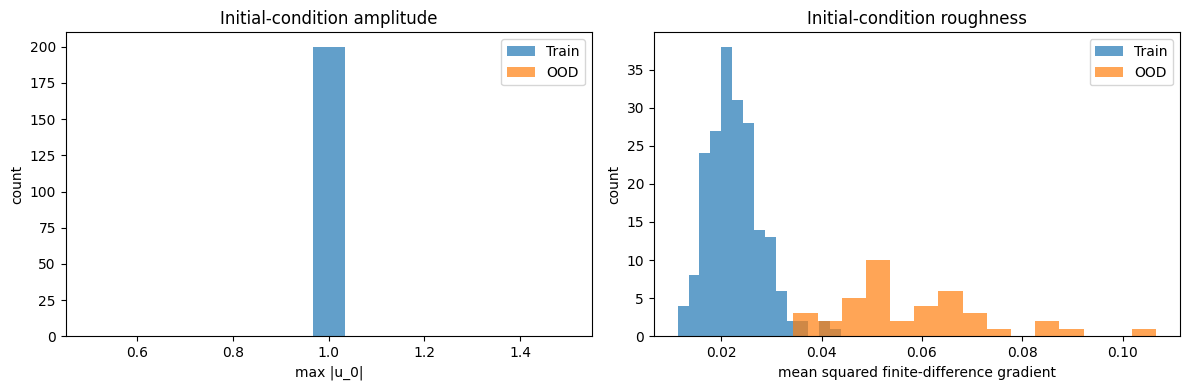

In [269]:
# Compare simple dataset-level summary statistics.
# The OOD histograms should shift toward larger amplitude and higher roughness.

train_amp = train_data["initial_field"].abs().amax(dim=(-1, -2))
ood_amp = ood_data["initial_field"].abs().amax(dim=(-1, -2))
train_rough = field_roughness(train_data["initial_field"])
ood_rough = field_roughness(ood_data["initial_field"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_amp.numpy(), bins=15, alpha=0.7, label="Train")
axes[0].hist(ood_amp.numpy(), bins=15, alpha=0.7, label="OOD")
axes[0].set_title("Initial-condition amplitude")
axes[0].set_xlabel("max |u_0|")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(train_rough.numpy(), bins=15, alpha=0.7, label="Train")
axes[1].hist(ood_rough.numpy(), bins=15, alpha=0.7, label="OOD")
axes[1].set_title("Initial-condition roughness")
axes[1].set_xlabel("mean squared finite-difference gradient")
axes[1].set_ylabel("count")
axes[1].legend()
plt.tight_layout()

## What is the neural operator input and output?

In this notebook, the neural operator learns the map

$$
\mathcal{G}: u_0(x,y) \mapsto u(x,y,T),
$$

where:

- $u_0(x,y)$ is the **initial condition field** at time $t=0$,
- $u(x,y,T)$ is the **solution field at a fixed final time** $T$.

### Input to the operator

The input is a **coarse sampled version of the initial field**:

- physical meaning: the initial Burgers state,
- grid used for sensing: `16 x 16`,
- tensor shape used by the model: `[batch, 16*16] = [batch, 256]`.

So each training example gives the model one flattened initial-condition field.

### Output of the operator

The output is the **entire predicted solution field at the final time**:

- physical meaning: the Burgers solution after evolution to time $T$,
- output/query grid: `32 x 32`,
- tensor shape produced by the model: `[batch, 32*32] = [batch, 1024]`.

For plotting, this flattened output is reshaped back to `[batch, 32, 32]`.

### Why this is called an operator

A standard neural network usually maps a vector to a scalar or a small vector. Here, the model maps **one function** (the initial field) to **another function** (the final field). That function-to-function map is the operator being learned.

### DeepONet view in this notebook

- the **branch network** reads the sampled input function $u_0$,
- the **trunk network** reads spatial coordinates $(x,y)$,
- the fused representation is decoded into the value of the output field on the fixed query grid.

Because this notebook uses a fixed query grid, the default `forward()` returns the whole output field in one call. That makes it compatible with the current `LaplaceWrapper` API.


## Data loaders and DeepONet model

Each training sample is one initial condition. The target is the **entire final field** on the fixed query grid. This is the key reason the model can be used directly with `LaplaceWrapper`.


### Why the residual model is easier to train

Predicting the whole final field from scratch is unnecessarily difficult here because the final Burgers state is still strongly related to the initial condition.

The notebook therefore uses a **residual operator model**:

- first upsample the coarse sensor field to the output grid,
- then let `DeepONet2D` learn only the correction needed to match the true PDE solution.

This is a logical scientific-ML bias: the network spends capacity on the genuinely nonlinear evolution rather than relearning the entire low-frequency field structure.

In [270]:
# Neural-operator tensor contract used throughout the notebook:
# - input  : flattened coarse initial field, shape [batch, 256]
# - output : flattened final field on the query grid, shape [batch, 1024]
# The field is reshaped back to [batch, 32, 32] for all spatial plots.

# Prepare training targets and instantiate the residual DeepONet.
# - Targets are flattened because the model outputs the whole field as one vector.
# - `ResidualFieldDeepONet` predicts a correction on top of an upsampled baseline.
# - `residual_scale` keeps the correction magnitude in a reasonable range.

train_targets = train_data["target_field"].reshape(config.n_train, -1)
val_targets = val_data["target_field"].reshape(config.n_val, -1)
test_targets = test_data["target_field"].reshape(config.n_test, -1)
ood_targets = ood_data["target_field"].reshape(config.n_ood, -1)

train_loader = DataLoader(TensorDataset(train_data["branch"], train_targets), batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_data["branch"], val_targets), batch_size=config.batch_size)


def upsample_branch_to_field(branch_inputs: torch.Tensor, cfg: ExperimentConfig) -> torch.Tensor:
    fields = branch_inputs.reshape(-1, 1, cfg.sensor_resolution, cfg.sensor_resolution)
    upsampled = F.interpolate(
        fields,
        size=(cfg.field_resolution, cfg.field_resolution),
        mode="bilinear",
        align_corners=False,
    )
    return upsampled[:, 0].reshape(branch_inputs.size(0), -1)


class ResidualFieldDeepONet(nn.Module):
    def __init__(self, cfg: ExperimentConfig, query_grid: torch.Tensor, residual_scale: float) -> None:
        super().__init__()
        self.cfg = cfg
        self.residual_scale = float(residual_scale)
        self.core = DeepONet2D(
            branch_input_dim=cfg.sensor_resolution * cfg.sensor_resolution,
            trunk_input_dim=2,
            latent_dim=cfg.latent_dim,
            hidden_dim=cfg.hidden_dim,
            depth=cfg.depth,
            query_grid=query_grid,
        )

    def forward(self, branch_inputs: torch.Tensor) -> torch.Tensor:
        baseline = upsample_branch_to_field(branch_inputs, self.cfg)
        correction = self.residual_scale * self.core(branch_inputs)
        return baseline + correction


train_baseline = upsample_branch_to_field(train_data["branch"], config)
residual_scale = (train_targets - train_baseline).std().item()

model = ResidualFieldDeepONet(
    config,
    query_grid=query_grid,
    residual_scale=residual_scale,
).to(device)

print(f"Residual correction scale: {residual_scale:.4f}")
model

Residual correction scale: 0.1170


ResidualFieldDeepONet(
  (core): DeepONet2D(
    (branch_net): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): Tanh()
      (6): Linear(in_features=128, out_features=128, bias=True)
    )
    (trunk_net): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): Tanh()
      (6): Linear(in_features=128, out_features=128, bias=True)
    )
    (output_head): Linear(in_features=128, out_features=1, bias=True)
  )
)

## MAP training

The notebook now uses a more explicit training strategy:

- a **residual DeepONet** predicts a correction on top of an interpolated sensor-field baseline,
- `AdamW` provides stable optimization with light regularization,
- `OneCycleLR` gives a clear learning-rate schedule,
- a small **gradient-matching penalty** encourages better spatial structure,
- **early stopping is optional** and controlled from the config.

Important config switches:

- `use_early_stopping=True`: stop when validation MSE stops improving.
- `use_early_stopping=False`: always train for the full number of epochs.
- `min_epochs`: prevents stopping too early.
- `early_stopping_min_delta`: minimum validation improvement required to reset patience.

### What to look for in the training curves

The training section now tracks three signals:

- **Train MSE**: the main pointwise field reconstruction error on the training set.
- **Gradient loss**: how well the model matches local spatial structure.
- **Validation MSE / RMSE**: the quantity used to decide whether the learned operator generalizes.

If the validation curve flattens while training loss keeps dropping, the model is starting to overfit. That is the main reason the optional early-stopping logic is included.

In [271]:
# Training helpers
# - `field_gradient_mismatch`: encourages spatial-structure fidelity.
# - `evaluate_loader`: validation MSE / RMSE.
# - `train_map_model`: deterministic MAP-style optimization loop.
# The optimizer sees both pointwise error and derivative mismatch.

def field_gradient_mismatch(pred: torch.Tensor, target: torch.Tensor, field_resolution: int) -> torch.Tensor:
    pred_field = pred.reshape(pred.size(0), field_resolution, field_resolution)
    target_field = target.reshape(target.size(0), field_resolution, field_resolution)
    gx_pred = torch.roll(pred_field, shifts=-1, dims=-2) - pred_field
    gx_true = torch.roll(target_field, shifts=-1, dims=-2) - target_field
    gy_pred = torch.roll(pred_field, shifts=-1, dims=-1) - pred_field
    gy_true = torch.roll(target_field, shifts=-1, dims=-1) - target_field
    return F.mse_loss(gx_pred, gx_true) + F.mse_loss(gy_pred, gy_true)


def evaluate_loader(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb, reduction="sum")
            total_loss += loss.item()
            total_count += yb.numel()
    mse = total_loss / max(total_count, 1)
    rmse = math.sqrt(mse)
    return mse, rmse


def relative_l2_error(pred, target):
    numerator = torch.linalg.norm(pred - target)
    denominator = torch.linalg.norm(target).clamp_min(1e-8)
    return (numerator / denominator).item()


def train_map_model(model, train_loader, val_loader, cfg, device):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=cfg.max_lr,
        epochs=cfg.epochs,
        steps_per_epoch=len(train_loader),
        pct_start=cfg.scheduler_pct_start,
    )
    history = {
        "train_mse": [],
        "train_grad_loss": [],
        "train_total_loss": [],
        "val_mse": [],
        "val_rmse": [],
        "lr": [],
    }
    best_state = None
    best_val = float("inf")
    patience_counter = 0

    for epoch in range(cfg.epochs):
        model.train()
        running_data_loss = 0.0
        running_grad_loss = 0.0
        running_total_loss = 0.0
        running_count = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            data_loss = F.mse_loss(pred, yb)
            grad_loss = field_gradient_mismatch(pred, yb, cfg.field_resolution)
            total_loss = data_loss + cfg.grad_match_weight * grad_loss
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step()

            weight = yb.numel()
            running_data_loss += data_loss.item() * weight
            running_grad_loss += grad_loss.item() * weight
            running_total_loss += total_loss.item() * weight
            running_count += weight

        train_mse = running_data_loss / max(running_count, 1)
        train_grad = running_grad_loss / max(running_count, 1)
        train_total = running_total_loss / max(running_count, 1)
        val_mse, val_rmse = evaluate_loader(model, val_loader, device)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_mse"].append(train_mse)
        history["train_grad_loss"].append(train_grad)
        history["train_total_loss"].append(train_total)
        history["val_mse"].append(val_mse)
        history["val_rmse"].append(val_rmse)
        history["lr"].append(current_lr)

        improved = val_mse < (best_val - cfg.early_stopping_min_delta)
        if improved:
            best_val = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1:03d} | train_mse={train_mse:.6f} | "
                f"train_grad={train_grad:.6f} | val_mse={val_mse:.6f} | "
                f"val_rmse={val_rmse:.6f} | lr={current_lr:.6e}"
            )

        if (
            cfg.use_early_stopping
            and epoch + 1 >= cfg.min_epochs
            and patience_counter >= cfg.patience
        ):
            print(f"Early stopping at epoch {epoch + 1}.")
            break

    if best_state is not None and cfg.use_early_stopping:
        model.load_state_dict(best_state)
    elif best_state is not None:
        # Even when early stopping is disabled, we still report the best validation
        # checkpoint in the history. The final model remains the fully trained one.
        print("Early stopping disabled: keeping final epoch weights.")

    return history


history = train_map_model(model, train_loader, val_loader, config, device)

Epoch 001 | train_mse=0.013702 | train_grad=0.005006 | val_mse=0.014373 | val_rmse=0.119887 | lr=8.084381e-05


Epoch 020 | train_mse=0.013186 | train_grad=0.004767 | val_mse=0.013759 | val_rmse=0.117301 | lr=3.982485e-04
Epoch 040 | train_mse=0.013151 | train_grad=0.004762 | val_mse=0.013766 | val_rmse=0.117328 | lr=1.141990e-03
Epoch 060 | train_mse=0.011792 | train_grad=0.004560 | val_mse=0.012357 | val_rmse=0.111162 | lr=1.818110e-03
Epoch 080 | train_mse=0.011065 | train_grad=0.004401 | val_mse=0.011741 | val_rmse=0.108356 | lr=1.999296e-03
Epoch 100 | train_mse=0.009932 | train_grad=0.004139 | val_mse=0.011023 | val_rmse=0.104989 | lr=1.982869e-03
Epoch 120 | train_mse=0.009104 | train_grad=0.003936 | val_mse=0.010274 | val_rmse=0.101363 | lr=1.944998e-03
Epoch 140 | train_mse=0.007735 | train_grad=0.003577 | val_mse=0.009758 | val_rmse=0.098782 | lr=1.886511e-03
Epoch 160 | train_mse=0.007007 | train_grad=0.003376 | val_mse=0.008952 | val_rmse=0.094616 | lr=1.808683e-03
Epoch 180 | train_mse=0.006678 | train_grad=0.003251 | val_mse=0.008963 | val_rmse=0.094671 | lr=1.713213e-03
Epoch 200 

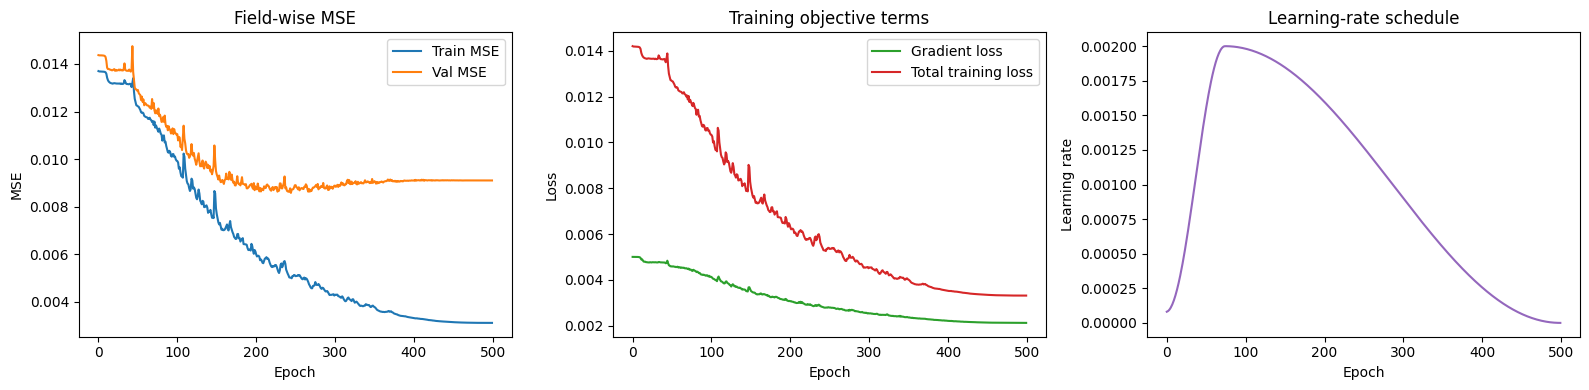

In [272]:
# Plot the training traces.
# The goal is to make optimization behavior interpretable, not just report one final number.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history["train_mse"], label="Train MSE")
axes[0].plot(history["val_mse"], label="Val MSE")
axes[0].set_title("Field-wise MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history["train_grad_loss"], label="Gradient loss", color="tab:green")
axes[1].plot(history["train_total_loss"], label="Total training loss", color="tab:red")
axes[1].set_title("Training objective terms")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(history["lr"], color="tab:purple")
axes[2].set_title("Learning-rate schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
plt.tight_layout()

MAP test RMSE: 0.09543
MAP OOD RMSE:  0.16219


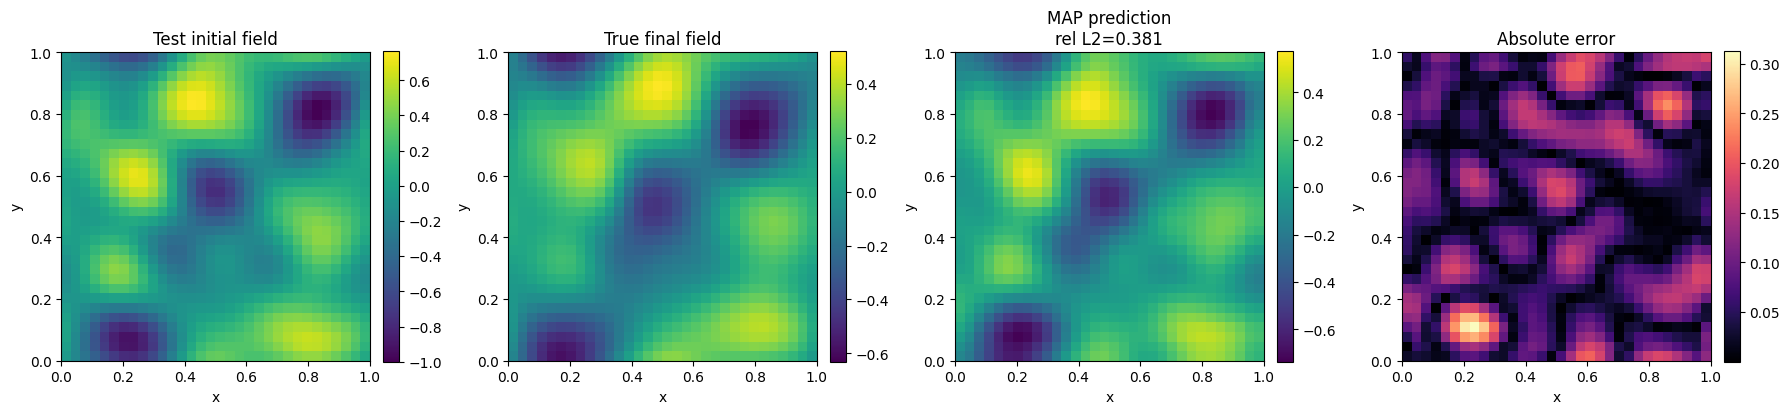

In [273]:
# Evaluate the trained MAP model on the test and OOD sets before fitting Laplace.
# This gives a deterministic baseline for all later uncertainty plots.

model.eval()
with torch.no_grad():
    test_pred = model(test_data["branch"].to(device)).cpu().reshape(config.n_test, config.field_resolution, config.field_resolution)
    ood_pred = model(ood_data["branch"].to(device)).cpu().reshape(config.n_ood, config.field_resolution, config.field_resolution)

sample_idx = 0
sample_true = test_data["target_field"][sample_idx]
sample_pred = test_pred[sample_idx]
sample_err = (sample_pred - sample_true).abs()
rel_l2 = relative_l2_error(sample_pred, sample_true)
map_test_rmse = torch.sqrt(torch.mean((test_pred - test_data["target_field"]) ** 2)).item()
map_ood_rmse = torch.sqrt(torch.mean((ood_pred - ood_data["target_field"]) ** 2)).item()
print(f"MAP test RMSE: {map_test_rmse:.5f}")
print(f"MAP OOD RMSE:  {map_ood_rmse:.5f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
plot_field(axes[0], test_data["initial_field"][sample_idx], "Test initial field")
plot_field(axes[1], sample_true, "True final field")
plot_field(axes[2], sample_pred, f"MAP prediction\nrel L2={rel_l2:.3f}")
plot_field(axes[3], sample_err, "Absolute error", cmap="magma")
plt.tight_layout()

## Additional MAP diagnostics

A single sample can hide failure modes. The next plots inspect multiple test cases and also compare **centerline slices** through the predicted fields. This makes it easier to see where the surrogate is smoothing sharp regions or missing local structure.

### Interpreting the MAP diagnostics

At this stage there is **no uncertainty model yet**. We are only checking whether the deterministic surrogate is trustworthy enough to deserve a posterior approximation.

Use the plots in this section to answer three questions:

1. Does the predicted field visually follow the true Burgers solution?
2. Are the largest errors concentrated near sharper spatial structures?
3. Do the 1D centerline slices show systematic smoothing or phase error?

If the MAP model is poor, a later Laplace approximation will not fix the underlying surrogate.

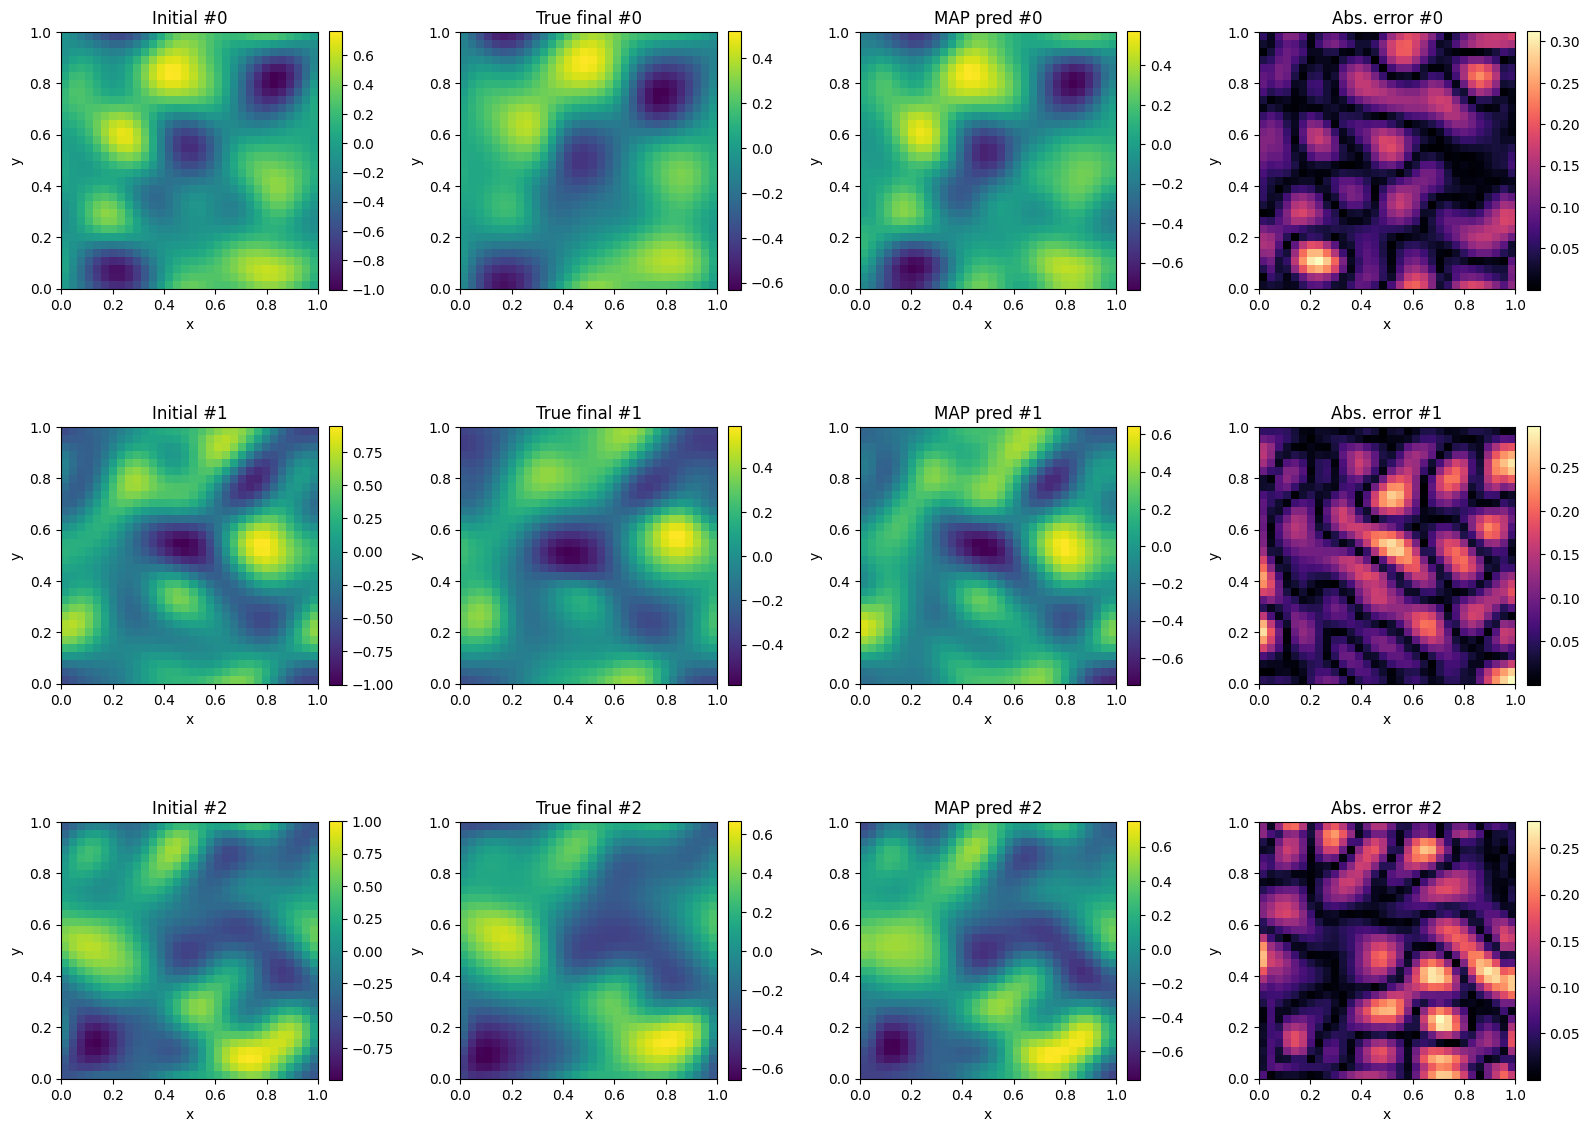

In [274]:
# Visualize several MAP predictions, not just one example.
# Multiple samples make recurring error patterns easier to spot.

map_ids = [0, 1, 2]
fig, axes = plt.subplots(len(map_ids), 4, figsize=(16, 4 * len(map_ids)))
for row, idx in enumerate(map_ids):
    true_field = test_data["target_field"][idx]
    pred_field = test_pred[idx]
    err_field = (pred_field - true_field).abs()
    plot_field(axes[row, 0], test_data["initial_field"][idx], f"Initial #{idx}")
    plot_field(axes[row, 1], true_field, f"True final #{idx}")
    plot_field(axes[row, 2], pred_field, f"MAP pred #{idx}")
    plot_field(axes[row, 3], err_field, f"Abs. error #{idx}", cmap="magma")
plt.tight_layout()

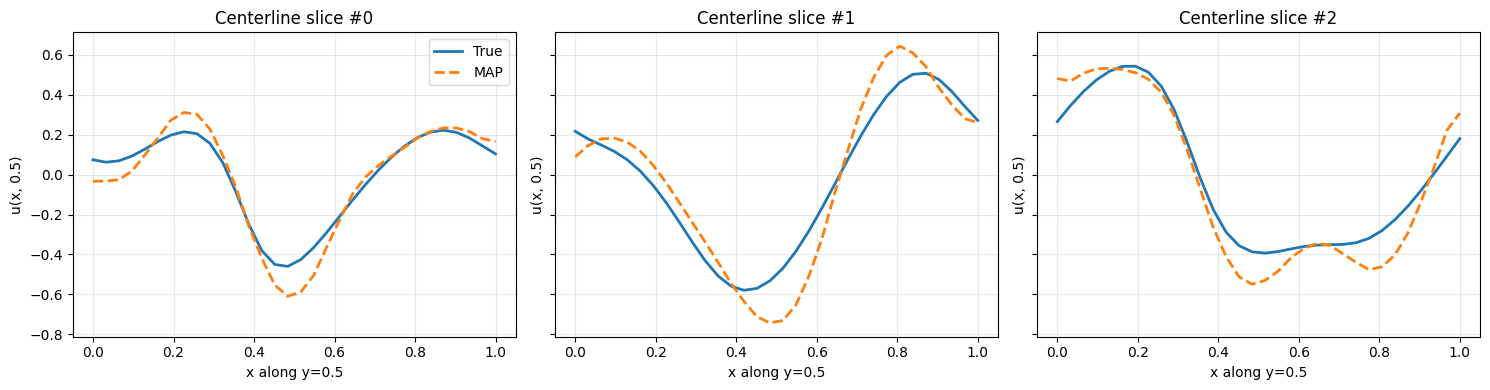

In [275]:
# 1D centerline slices are a compact way to compare field shapes.
# They often reveal smoothing or phase errors more clearly than heatmaps alone.

mid = config.field_resolution // 2
fig, axes = plt.subplots(1, len(map_ids), figsize=(5 * len(map_ids), 4), sharey=True)
if len(map_ids) == 1:
    axes = [axes]
for ax, idx in zip(axes, map_ids):
    x_axis = np.linspace(0.0, 1.0, config.field_resolution)
    ax.plot(x_axis, test_data["target_field"][idx][mid].numpy(), label="True", linewidth=2)
    ax.plot(x_axis, test_pred[idx][mid].numpy(), label="MAP", linewidth=2, linestyle="--")
    ax.set_title(f"Centerline slice #{idx}")
    ax.set_xlabel("x along y=0.5")
    ax.set_ylabel("u(x, 0.5)")
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()

## Animated true-vs-predicted fields

Static figures are useful, but learners often understand an operator model faster when they can watch several samples in sequence.

The next cell creates GIFs that cycle through multiple examples and show:

- the initial field,
- the true Burgers solution at the final time,
- the MAP-predicted field,
- the absolute error.

This is helpful for spotting repeated behaviors such as smoothing bias, missed sharp regions, or systematically harder OOD cases.


## Laplace approximation on the trained DeepONet

We now reuse the existing Deep-UQ Laplace implementation. The main path is:

- regression likelihood,
- last-layer subset,
- diagonal curvature.

The predictive mean should stay close to the MAP model, while the variance captures posterior uncertainty in the final readout layer.


### What Laplace is doing here

The Laplace approximation is applied **after** MAP training. It does not retrain the network from scratch.

Instead, it:

- treats the trained weights as a local posterior mode,
- approximates uncertainty around that mode,
- samples from the resulting local Gaussian approximation,
- converts those weight samples into predictive mean and variance fields.

Because this notebook uses `subset_of_weights="last_layer"`, the uncertainty is concentrated in the final readout head rather than the entire DeepONet.

In [277]:
# Fit a last-layer diagonal Laplace approximation.
# The stronger prior precision keeps the posterior mean close to the well-trained MAP model.

# A stronger prior precision keeps the last-layer posterior close to the trained
# MAP solution while still exposing epistemic uncertainty through sampled weights.
laplace_diag = LaplaceWrapper(
    model,
    likelihood="regression",
    hessian_structure="diag",
    subset_of_weights="last_layer",
)
laplace_diag.fit(train_loader, prior_precision=100.0)

In [278]:
# Convert the generic UQResult tensors into 2D fields.
# This helper is the bridge between the library output contract and spatial visualization.


def laplace_field_uq(wrapper, branch_inputs, cfg, device, n_samples=20):
    wrapper.model.eval()
    uq = wrapper.predict_uq(branch_inputs.to(device), n_samples=n_samples)
    mean = uq.mean.detach().cpu().reshape(-1, cfg.field_resolution, cfg.field_resolution)
    total_var = uq.total_var.detach().cpu().reshape(-1, cfg.field_resolution, cfg.field_resolution)
    epistemic_var = uq.epistemic_var
    if epistemic_var is None:
        epistemic = total_var.clone()
    else:
        epistemic = epistemic_var.detach().cpu().reshape(-1, cfg.field_resolution, cfg.field_resolution)
    std = total_var.clamp_min(0.0).sqrt()
    return mean, epistemic, total_var, std


diag_mean_test, diag_epi_test, diag_var_test, diag_std_test = laplace_field_uq(
    laplace_diag,
    test_data["branch"],
    config,
    device,
    n_samples=config.laplace_samples,
)

diag_mean_ood, diag_epi_ood, diag_var_ood, diag_std_ood = laplace_field_uq(
    laplace_diag,
    ood_data["branch"],
    config,
    device,
    n_samples=config.laplace_samples,
)


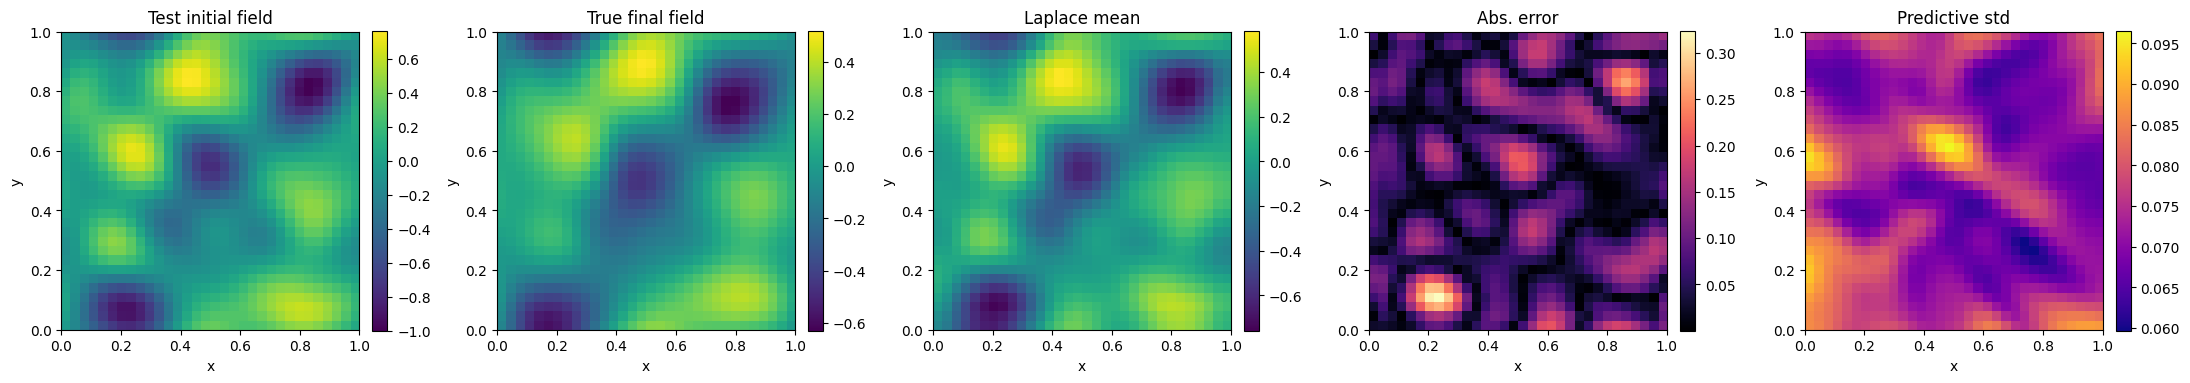

In [279]:
# Test-set uncertainty visualization.
# Read it left-to-right: input, truth, predictive mean, error, predictive standard deviation.


fig, axes = plt.subplots(1, 5, figsize=(22, 4))
plot_field(axes[0], test_data["initial_field"][sample_idx], "Test initial field")
plot_field(axes[1], sample_true, "True final field")
plot_field(axes[2], diag_mean_test[sample_idx], "Laplace mean")
plot_field(axes[3], (diag_mean_test[sample_idx] - sample_true).abs(), "Abs. error", cmap="magma")
plot_field(axes[4], diag_std_test[sample_idx], "Predictive std", cmap="plasma")
plt.tight_layout()


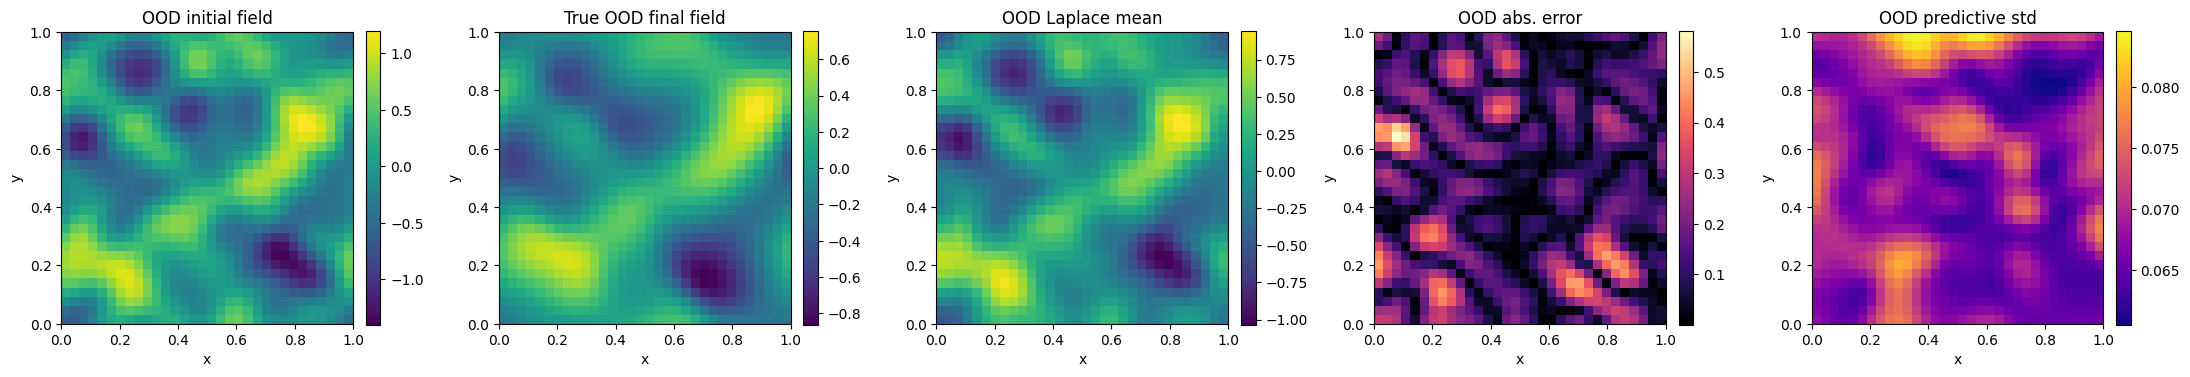

In [280]:
# Repeat the same uncertainty visualization on an OOD sample.
# The important comparison is whether uncertainty expands on the harder input.


ood_idx = 0
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
plot_field(axes[0], ood_data["initial_field"][ood_idx], "OOD initial field")
plot_field(axes[1], ood_data["target_field"][ood_idx], "True OOD final field")
plot_field(axes[2], diag_mean_ood[ood_idx], "OOD Laplace mean")
plot_field(axes[3], (diag_mean_ood[ood_idx] - ood_data["target_field"][ood_idx]).abs(), "OOD abs. error", cmap="magma")
plot_field(axes[4], diag_std_ood[ood_idx], "OOD predictive std", cmap="plasma")
plt.tight_layout()


## Aggregate uncertainty diagnostics

The sample-level plots are useful, but uncertainty is easier to trust when it is also summarized across the whole dataset. The next plots show:

- average standard deviation fields for test and OOD cases,
- average absolute error fields,
- sample-wise relationships between RMSE and average predicted standard deviation.

### Reading the uncertainty plots

The uncertainty figures are most useful when compared against the error figures.

A good qualitative pattern is:

- lower standard deviation on training-like smooth inputs,
- broader uncertainty on OOD inputs,
- larger uncertainty where the deterministic field error is also larger.

The aggregate diagnostics below make this comparison easier by averaging over many samples instead of relying on one hand-picked example.

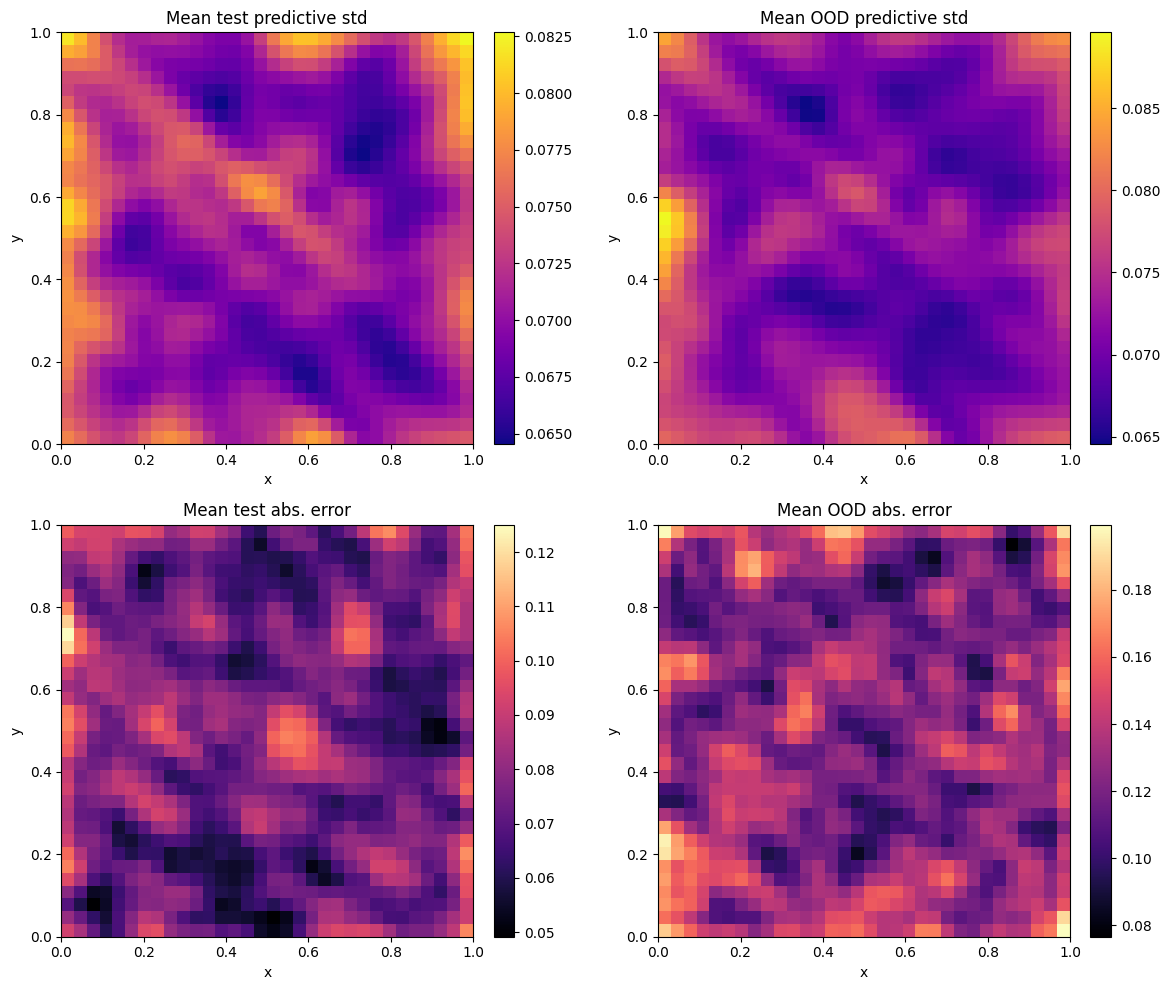

In [281]:
# Aggregate field diagnostics over the whole dataset.
# Averaged maps are useful because single-sample plots can be misleading.

test_abs_err = (diag_mean_test - test_data["target_field"]).abs()
ood_abs_err = (diag_mean_ood - ood_data["target_field"]).abs()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_field(axes[0, 0], diag_std_test.mean(dim=0), "Mean test predictive std", cmap="plasma")
plot_field(axes[0, 1], diag_std_ood.mean(dim=0), "Mean OOD predictive std", cmap="plasma")
plot_field(axes[1, 0], test_abs_err.mean(dim=0), "Mean test abs. error", cmap="magma")
plot_field(axes[1, 1], ood_abs_err.mean(dim=0), "Mean OOD abs. error", cmap="magma")
plt.tight_layout()

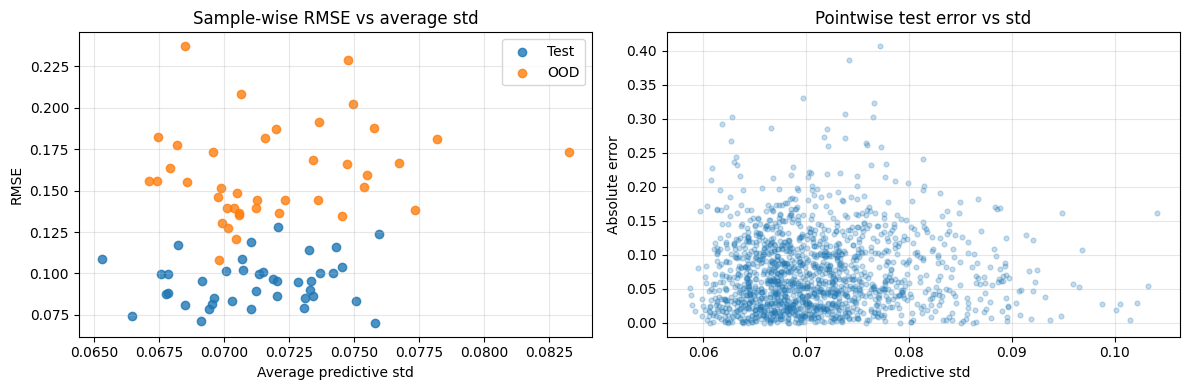

In [282]:
# Compare uncertainty against error in two ways:
# - sample-level RMSE vs average standard deviation,
# - pointwise error vs pointwise standard deviation.
# These plots help assess whether the uncertainty signal is at least directionally sensible.

test_rmse_per_sample = torch.sqrt(torch.mean((diag_mean_test - test_data["target_field"]) ** 2, dim=(-1, -2)))
ood_rmse_per_sample = torch.sqrt(torch.mean((diag_mean_ood - ood_data["target_field"]) ** 2, dim=(-1, -2)))
test_std_per_sample = diag_std_test.mean(dim=(-1, -2))
ood_std_per_sample = diag_std_ood.mean(dim=(-1, -2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(test_std_per_sample.numpy(), test_rmse_per_sample.numpy(), alpha=0.8, label="Test")
axes[0].scatter(ood_std_per_sample.numpy(), ood_rmse_per_sample.numpy(), alpha=0.8, label="OOD")
axes[0].set_title("Sample-wise RMSE vs average std")
axes[0].set_xlabel("Average predictive std")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_points = min(1500, test_abs_err.numel())
gen = torch.Generator().manual_seed(SEED)
flat_err = test_abs_err.reshape(-1)
flat_std = diag_std_test.reshape(-1)
perm = torch.randperm(flat_err.numel(), generator=gen)[:n_points]
axes[1].scatter(flat_std[perm].numpy(), flat_err[perm].numpy(), alpha=0.25, s=12)
axes[1].set_title("Pointwise test error vs std")
axes[1].set_xlabel("Predictive std")
axes[1].set_ylabel("Absolute error")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()

In [283]:
# Compact numeric summary to complement the visual diagnostics.
# RMSE measures accuracy; average/max std measure uncertainty magnitude.

def summarize_uncertainty(mean_field, std_field, target_field, label):
    rmse = torch.sqrt(torch.mean((mean_field - target_field) ** 2)).item()
    avg_std = std_field.mean().item()
    max_std = std_field.max().item()
    print(f"{label}: rmse={rmse:.5f}, avg_std={avg_std:.5f}, max_std={max_std:.5f}")

print(f"MAP test RMSE: {map_test_rmse:.5f}")
print(f"MAP OOD RMSE:  {map_ood_rmse:.5f}")
summarize_uncertainty(diag_mean_test, diag_std_test, test_data["target_field"], "Laplace test")
summarize_uncertainty(diag_mean_ood, diag_std_ood, ood_data["target_field"], "Laplace OOD")

MAP test RMSE: 0.09543
MAP OOD RMSE:  0.16219
Laplace test: rmse=0.09609, avg_std=0.07120, max_std=0.11306
Laplace OOD: rmse=0.16296, avg_std=0.07199, max_std=0.13730



## Optional curvature comparison: diagonal vs Kronecker

For this notebook, diagonal last-layer Laplace is the default because it is the most robust and quickest option. If `kron` is available and the quick configuration is disabled, you can compare the uncertainty maps.


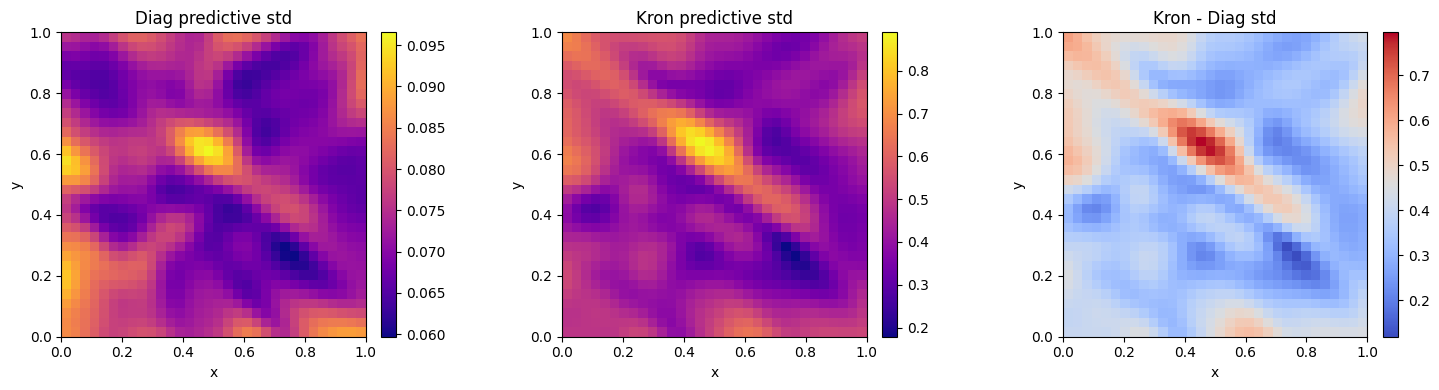

In [284]:
# Optional second-order comparison.
# This is intentionally secondary: diagonal last-layer Laplace is the main tutorial path.


if config.compare_kron:
    laplace_kron = LaplaceWrapper(
        model,
        likelihood="regression",
        hessian_structure="kron",
        subset_of_weights="last_layer",
    )
    laplace_kron.fit(train_loader, prior_precision=1.0)
    kron_mean_test, kron_epi_test, kron_var_test, kron_std_test = laplace_field_uq(
        laplace_kron,
        test_data["branch"],
        config,
        device,
        n_samples=config.laplace_samples,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plot_field(axes[0], diag_std_test[sample_idx], "Diag predictive std", cmap="plasma")
    plot_field(axes[1], kron_std_test[sample_idx], "Kron predictive std", cmap="plasma")
    plot_field(axes[2], (kron_std_test[sample_idx] - diag_std_test[sample_idx]), "Kron - Diag std", cmap="coolwarm")
    plt.tight_layout()
else:
    print("Kronecker comparison disabled in quick config.")



## Conclusions

This notebook demonstrates that the current Deep-UQ stack can already support a compact scientific machine learning example, provided the operator model is structured to match the existing uncertainty API.

Main takeaways:

- `DeepONet2D` can learn a low-resolution Burgers operator map from initial field to final field.
- Last-layer Laplace works without changing the core `LaplaceWrapper` API.
- OOD initial conditions tend to produce broader uncertainty maps than training-like smooth fields.
- The example is intentionally small; larger scientific ML studies would likely need stronger PDE solvers, larger datasets, and possibly richer posterior approximations.


### Limitations of this tutorial setup

This notebook is intentionally compact. It is a good introduction to the workflow, but it is not a production scientific-computing benchmark.

Main simplifications:

- scalar Burgers instead of a full vector fluid system,
- explicit finite-difference solver with safety clamps,
- one fixed output time rather than a full time-dependent operator,
- last-layer Laplace instead of a full-network posterior approximation.

Those choices keep the notebook readable and CPU-friendly while still demonstrating the key scientific machine learning idea: learning an operator map and attaching uncertainty to the resulting field prediction.